# 库导入

In [1]:
#  库导入
import numpy as np # 数值数学计算库
from scipy.integrate import quad # 积分计算库
from scipy import stats
from scipy.interpolate import interp1d # 做差值

import matplotlib.pyplot as plt # 绘图库
from matplotlib.ticker import FuncFormatter # 图表格式化库
from matplotlib.ticker import FormatStrFormatter

from typing import Tuple # 类型提示库
import pandas as pd # 使用pandas读取信息

from gapp import dgp,covariance # GP拟合方法库

from astropy.cosmology import FlatLambdaCDM
from astropy import constants as const
import astropy.units as u
from astropy.cosmology import z_at_value


In [2]:
# import gapp as dgp

# 全局量设置

In [3]:
# 定义全局常量
np.random.seed(202506012)
# 光速
c_light=const.c.to(u.km/u.s).value  # 定义天文学中的光速
c_mpc_yr=const.c.to(u.Mpc/u.yr) # 将光速转化为Mpc/year 的情况

# 万有引力常数
Msun = const.M_sun
constG = 4.3009e-3

constc=const.c.to(u.Mpc/u.s).value # 转换换单位为 Mpc³ / (Msun·s²)，方便天体物理和宇宙学单位下使用
 
#ACDM标准宇宙学模型=cosmo内储存了一些常量+cosmo可以计算很多宇宙学（依据其所储存的常量）量
cosmo=FlatLambdaCDM(H0=67.64,Om0=0.3087)

In [4]:
print(c_light/67.64)

4432.1770845653455


In [5]:
def bar(i,n): 
    i=i+1
    print('\r['+'#'*int(40*i/n)+' '*(40-int(40*i/n))+']',end='')

# 用于计算的理论函数区（计算器）

In [6]:
# 计算ACDM模型下的红移与光度距离关系（标准电磁波光度距离 (LambdaCDM)）
# 输入：一维红移数组 -> 输出：二维数组[][] 红移,光度距离
def GW_calculate_ACDM(H0:float=67.64, Omega_M:float=0.3087, z=None, c:float=299792.458):
        """
        计算ACDM模型下的光度距离随红移的关系
        参数:
            H0       : 哈勃常数, km/s/Mpc
            Omega_M  : 物质密度参数
            n_points : 红移点数
            c        : 光速, km/s
        返回:
            z_vals  : 红移数组, numpy.ndarray
            dL_vals : 对应光度距离数组, numpy.ndarray, 单位Mpc
        """
        # 定义光度距离函数
        def d_L_em(z):
            def integrand(zp):
                return 1.0 / np.sqrt(Omega_M*(1+zp)**3 + (1-Omega_M))
            integral, _ = quad(integrand, 0, z)
            return (1 + z) * (c / H0) * integral

        # 向量化函数
        d_L_em_vec = np.vectorize(d_L_em)

        # 红移数组
        z_vals = np.array(z)  # 确保 z 是 numpy 数组
        dL_vals = d_L_em_vec(z_vals)
        
        ACDM_theory_data = np.column_stack((z_vals, dL_vals))
        return ACDM_theory_data 

In [7]:
# 计算RT模型下的红移与光度距离关系
# 输入：一维红移数组 -> 输出：二维数组[][] 红移,光度距离
def GW_calculate_RT(Xi:float=1.67, n:float=1.94, z=None, c:float=299792.458):
    data = GW_calculate_ACDM(H0=67.64, Omega_M=0.3087, z=z, c=c)
    X = data[:,0]
    Y = data[:,1]
    Y_RT = Y * (Xi + (1 - Xi)/((1 + X)**n))
    RT_theory_data = np.column_stack((X, Y_RT))
    return RT_theory_data


### 修正均值函数

In [8]:
# 高斯过程的先验均值函数：RT 模型
# x: 红移数组 (N, ) 或 (N, 1)；Xi, n: RT 模型的修正，参H0, Omega_M: 宇宙学背景参数
def mu_RT_model(x, Xi, n, H0, Omega_M):
    z = x.flatten()
    data = GW_calculate_ACDM(H0=H0, Omega_M=Omega_M, z=z, c=299792.458)
    dL_em = data[:,1]
    # 第二步：应用 RT 模型的修正公式   
    # d_L^GW = d_L^EM * (Xi + (1 - X) / (1 + z)^n)
    dL_gw = dL_em * (Xi + (1.0 - Xi) / ((1.0 + z)**n))
    return dL_gw

In [9]:
# Xi, n, H0, Omega_M
my_muargs = (1.67, 1.94, 67.64, 0.3087)

# 用于画图的理论函数区

In [10]:
# 计算ACDM模型下的红移与光度距离关系（平均红移点）
# 输入：(ACDM模型参数 H0, Ωm, (计算参数) 红移最大值, 红移点数(会变成均匀的)) -> 输出：二维数组 红移值，光度距离
def GW_forplot_ACDM(H0:float=67.64, Omega_M:float=0.3087, z_max:float=5, n_points:int=200, c:float=299792.458):
    """
    计算ACDM模型下的光度距离随红移的关系
    参数:
        H0       : 哈勃常数, km/s/Mpc
        Omega_M  : 物质密度参数
        z_max    : 红移最大值
        n_points : 红移点数
        c        : 光速, km/s
    返回:
        z_vals  : 红移数组, numpy.ndarray
        dL_vals : 对应光度距离数组, numpy.ndarray, 单位Mpc
    """
    # 定义光度距离函数
    def d_L_em(z):
        def integrand(zp):
            return 1.0 / np.sqrt(Omega_M*(1+zp)**3 + (1-Omega_M))
        integral, _ = quad(integrand, 0, z)
        return (1 + z) * (c / H0) * integral

    # 向量化函数
    d_L_em_vec = np.vectorize(d_L_em)

    # 红移数组
    z_vals = np.linspace(0, z_max, n_points)
    dL_vals = d_L_em_vec(z_vals)
    
    ACDM_theory_data = np.column_stack((z_vals, dL_vals))
    return ACDM_theory_data 


In [11]:
# 计算RT模型下的红移与光度距离关系
# 输入：(RT模型参数 Xi, n, (计算参数) 红移最大值, 红移点数(会变成均匀的)) -> 输出：二维数组 红移值，光度距离
def GW_forplot_RT(Xi:float=1.67, n:float=1.94,z_max:float=5, n_points:int=200, c:float=299792.458):
    data = GW_forplot_ACDM(H0=67.64, Omega_M=0.3087, z_max=z_max, n_points=n_points, c=c)
    X = data[:,0]
    Y = data[:,1]
    Y_RT = Y * (Xi + (1 - Xi)/((1 + X)**n))
    RT_theory_data = np.column_stack((X, Y_RT))
    return RT_theory_data


# "实验"数据处理

In [12]:
#  根据参数生成此高斯函数对应的 (x,y) 数据点 这里一共是400个点
# 输入：(均值，方差) -> 输出：对应高斯函数的点(x数组[]，y数组[]) NumPy 数组
# def gaussian(mu: float, sigma2: float) -> Tuple[np.ndarray, np.ndarray]:
#     sigma = np.sqrt(sigma2)
#     x = np.linspace(mu - 10*sigma, mu + 10*sigma, 4000) # 在中值和方差定义的范围内生成等距x值,共400个点
#     y = (1 / np.sqrt(2 * np.pi * sigma2)) * np.exp(- (x - mu)**2 / (2 * sigma2))
#     return x, y

In [13]:
# 根据高斯分布随机取点 从理论d_L值到实验d_L值
# 输入：(均值，方差，采样点数) -> 输出：采样点数组sample[]  NumPy 数组
def sample_from_gaussian(mu: float, sigma2: float, n_samples: int = 1) -> np.ndarray:
    if mu == 0 and sigma2 == 0:
        return np.zeros(n_samples)
    # x, y = gaussian(mu, sigma2)
    # y_prob = y / y.sum()  # 将高斯函数值归一化为概率[这里是离散取点]，这里的y_prob也是一个数组
    # samples = np.random.choice(x, size=n_samples, p=y_prob)  # 按概率抽样
    samples = np.random.normal(loc=mu, scale=sigma2, size=n_samples)
    return samples

In [14]:
# 数据CSV文件读取并输出
# 输入：CSV文件路径 -> 输出：原始数据的NumPy数组data_array[][]
def read_csv_to_numpy(file_path: str) -> np.ndarray:
    df = pd.read_csv(file_path)  # 文件路径可以是相对路径或绝对路径
    data_array = df.to_numpy()
    return data_array # 这里返回的是一个二维Numpy数组

In [15]:
# 读取CSV文件，生成随机样本，并返回处理后的的数据数组 实验dL值和z值组合为数组
# 输入：二维数组[][3] -> 输出：高斯撒点处理后的NumPy数组data_array[][]
def gaussianrandom_to_newnumpy(data:np.ndarray) -> np.ndarray:
    samples_list = []

    # 忽略第一列 z值保留
    mu_values = data[:, 1]      # 第二列    
    sigma2_values = data[:, 2]    # 第三列 标准差变为方差   
    for mu, sigma2 in zip(mu_values, sigma2_values):
        sample = sample_from_gaussian(mu, sigma2,1)
        samples_list.append(sample[0])  # sample 是数组，取第0个元素
    samples_array = np.array(samples_list)

    new_data = np.column_stack((data[:, 0], samples_array, data[:, 2]))
    return new_data

In [16]:
# 根据文件数据读取红移分布 根据ACDM生成样本，并返回处理后的的数据数组
# 输入：CSV文件路径 -> 输出：高斯撒点处理后的NumPy数组data_array[][]
def ACDM_csv_to_newnumpy(file_path: str) -> np.ndarray:
    data = read_csv_to_numpy(file_path)

    # 忽略第一列
    z_values = data[:, 0]      # 第一列
    data2 = GW_calculate_ACDM(H0=67.64, Omega_M=0.3087, z=z_values, c=299792.458)
    mu_values = data2[:,1]      # 第二列    
    fixed_data = np.column_stack((data[:, 0], mu_values, data[:, 2]))
    receive = gaussianrandom_to_newnumpy(fixed_data)
    return receive

In [17]:
# 读取根据文件数据，读取红移分布 根据ACDM生成样本，并返回处理后的的数据数组
# 输入：CSV文件路径 -> 输出：高斯撒点处理后的NumPy数组data_array[][]
def GT_csv_to_newnumpy(file_path: str) -> np.ndarray:
    data = read_csv_to_numpy(file_path)

    # 忽略第一列
    z_values = data[:, 0]      # 第一列
    data2 = GW_calculate_RT(Xi=1.67, n=1.94, z=z_values, c=299792.458)
    mu_values = data2[:,1]     # 第二列
    fixed_data = np.column_stack((data[:, 0], mu_values, data[:, 2]))
    receive = gaussianrandom_to_newnumpy(fixed_data)
    return receive

In [18]:
# 使用GaPP方法处理二维数组
# 输入：(二维数组data_array[][3], 以及模型参数) -> 输出：GaPP处理后的二维数组GaPP_data[][]
def gapp_solve(data:np.ndarray, xmin=0.0, xmax=10.0, nstar=200, initheta=[2.0,2.0],mu_func=None, mu_args=()):
    """
    对输入数据 X,Y,Sigma 执行 Gaussian Process 重构
    
    返回：
    - Xstar: 重构函数对应横坐标
    - rec: 重构函数
    - drec: 一阶导数
    - d2rec: 二阶导数
    - d3rec: 三阶导数
    """
    X = data[:,0]
    Y = data[:,1]
    Sigma = data[:,2]
    H0 = 67.64  # 哈勃常数，单位 km/s/Mpc

    # --- 逻辑处理 ：如果不传入 mu_func，则不使用均值函数 ---
    # 在 Python 中，如果 mu=None，GaPP 默认不启用先验均值函数
    selected_mu = mu_func
    selected_muargs = mu_args

    # 创建与样本长度一致的数组
    # n = len(X)
    # dX = np.full(n, np.nan)
    # dY = np.full(n, np.nan)
    # dSigma = np.full(n, np.nan)
   
    # dX_val = float(0.0)
    # dY_val = float(c_light/H0)
    # dSigma_val = float(0)

    # # 设置第一个位置
    # dX[0] = dX_val
    # dY[0] = dY_val
    # dSigma[0] = dSigma_val
    # initialization of the Gaussian Process
    g = dgp.DGaussianProcess(X, Y, Sigma, cXstar=(xmin, xmax, nstar), covfunction=covariance.Matern92,mu=selected_mu,muargs=selected_muargs,dX=0, dY=c_light/H0, dSigma=0, grad='False')

    # training of the hyperparameters and reconstruction of the function
    (rec, theta) = g.gp(theta=initheta)
    # 注意rec是重构函数的二维数组 横坐标[:,0] , 纵坐标[:,1] , 误差值[:,2]

    # reconstruction of the first, second and third derivatives.
    # theta is fixed to the previously determined value.
    (drec, theta) = g.dgp(thetatrain='False')
    (d2rec, theta) = g.d2gp()
    (d3rec, theta) = g.d3gp()
    
    # 用字典返回多个值
    result = {
        "X": X,
        "Y": Y,
        "Sigma": Sigma,
        "rec": rec,
        "drec": drec,
        "d2rec": d2rec,
        "d3rec": d3rec,
        "theta": theta
    }
    return result

# Montecarlo处理

## Montecarlo功能函数

In [19]:
# 数列根据第一行排序处理
# 1 个 二维数组[][3] -> 输出 ：1 个 根据x从小到大排序好后的 二维数组[][3]
def sort_by_x(array):
    """
    输入:  array  -> 任意形状为 Nx3 的二维数组
    输出:  排序后的数组（按第 0 列 x 从小到大）
    """
    # 根据第0列进行排序
    idx = np.argsort(array[:, 0])
    return array[idx]

In [20]:
# 插值处理
# 2 个 二维数组[][3] -> 输出 ：2 个 匹配X值后的 二维数组[][3]
def interpolate_to_B_grid(arrayA, arrayB, kind='linear'):
    """
    输入:
        arrayA: Nx3  [xA, yA, sigmaA]
        arrayB: Mx3  [xB, yB, sigmaB]
    输出:
        newA: Mx3    [xB, yA_interp, sigmaA_interp]
        newB: Mx3    [xB, yB, sigmaB]  (与输入相同)
    """
    arrayA = sort_by_x(arrayA)
    arrayB = sort_by_x(arrayB)
    # A 的原始数据
    xA = arrayA[:,0]
    yA = arrayA[:,1]
    sA = arrayA[:,2]

    # B 的目标 x 网格
    xB = arrayB[:,0]

    # ---- 给 A 做插值，使其在 B 的 x 网格上重采样 ----
    yA_f = interp1d(xA, yA, kind=kind, bounds_error=False, fill_value="extrapolate")
    sA_f = interp1d(xA, sA, kind=kind, bounds_error=False, fill_value="extrapolate")

    yA_interp = yA_f(xB)
    sA_interp = sA_f(xB)

    # newA 格式： [xB, yA(xB), sigmaA(xB)]
    newA = np.column_stack([xB, yA_interp, sA_interp])

    # newB 就是 arrayB 本身
    newB = arrayB.copy()

    return newA, newB

In [21]:
# 根据一个高斯分布的均值和误差进行蒙特卡洛撒点
# 主要输入： 一个均值和标准差 -> 输出： 采样得到的5000000个点
def montecarlo_gaussian(mu,sigma,n_sample=500000,random_seed=None):
    if random_seed is not None:
        np.random.seed(random_seed)
    
    # 生成高斯分布的随机样本
    samples = np.random.normal(loc=mu, scale=sigma, size=n_sample)
    
    return samples

In [22]:
# 分析一维数组 给出不同的分位数
# 输入：一维数组 -> 输出 ： 一组指定的分位数
def anaylize_array(sample):
    sample = np.asarray(sample)
    # 忽略 NaN
    sample = sample[~np.isnan(sample)]
    # mean = np.mean(sample)
    # std = np.std(sample, ddof=1)  # ddof=1 表示无偏估计
    p50 = np.percentile(sample, 50)
    p2o5 = np.percentile(sample, 2.5)
    p97o5 = np.percentile(sample, 97.5)
    p16 = np.percentile(sample, 16)
    p84 = np.percentile(sample, 84)
    return p50, p2o5, p97o5, p16, p84

## Montecarl处理具体问题

### 光度距离比值 ratio

In [23]:
# 根据一组 两队的均值和误差进行撒点后 计算比值
# 主要输入： 两对均值和标准差 -> 输出： 一组500000个的比值
def montecarlo_ratio(meanA,stdA,meanB,stdB,n_sample):
    samplesA = montecarlo_gaussian(meanA,stdA,n_sample)
    samplesB = montecarlo_gaussian(meanB,stdB,n_sample)
    ratio = samplesA / np.where(samplesB == 0, np.nan, samplesB) # 避免除以0

    return ratio

In [24]:
# 输入 :2 个 二维数组[][3] -> 输出 ：1 个 二维数组[][3]
def montecarlo_ratio_group(arrayA,arrayB,n_sample=500000):
    arrayA,arrayB=interpolate_to_B_grid(arrayA,arrayB)
    ratio_results = []
    print("montecarlo_ratio_group")
    for i in range(len(arrayA)):
        z = arrayA[i, 0]                      # 当前行的 z 值
        meanA, stdA = arrayA[i, 1], arrayA[i, 2]
        meanB, stdB = arrayB[i, 1], arrayB[i, 2]
        p50, p2o5, p97o5, p16, p84 = anaylize_array(montecarlo_ratio(meanA,stdA,meanB,stdB,n_sample))
        ratio_results.append([z, p50, p2o5, p97o5, p16, p84])
        bar(i,len(arrayA))

    # ratio_results.append([z, mean, std])
    return np.array(ratio_results)

### 有效牛顿引力常数G

In [25]:
# 输出一组500000个的
def montecarlo_gravity(meanA,stdA,n_sample,mu=1):
    samplesA = montecarlo_gaussian(meanA,stdA,n_sample)
    Geff = (samplesA**2 )

    return Geff

In [26]:
# 输入 :1 个 二维数组[][3] -> 输出 ：1 个 二维数组[][3]
def montecarlo_gravity_group(arrayA,n_sample=500000):
    gravity_results = []
    print("\n montecarlo_gravity_group")
    for i in range(len(arrayA)):
        z = arrayA[i, 0]                      # 当前行的 z 值
        meanA = arrayA[i, 1]
        stdA = (arrayA[i,5]-arrayA[i,4])/2
        p50, p2o5, p97o5, p16, p84 = anaylize_array(montecarlo_gravity(meanA,stdA,n_sample))
        gravity_results.append([z, p50, p2o5, p97o5, p16, p84])
        bar(i,len(arrayA))
    # gravity_results.append([z, mean, std])
    return np.array(gravity_results)

### 时空维度D

In [27]:
def montecarlo_dimention(meanA,stdA,meanB,stdB,n_sample):
    samplesA = montecarlo_gaussian(meanA,stdA,n_sample)
    samplesB = montecarlo_gaussian(meanB,stdB,n_sample)
    
    n = 1
    Rc = 4400 # Mpc
    # 构造公式中的分子部分: 2 * n * ln(dL_GW / dL_EM)
    numerator = 2 * n * np.log(samplesA / samplesB)
    # 构造公式中的分母部分: ln(1 + (dL_EM / Rc)^n)
    denominator = np.log(1 + (samplesB / Rc)**n)
    # 计算 D
    D = 4 + (numerator / denominator)
    
    return D

    

In [28]:
def montecarlo_dimention_group(arrayA,arrayB,n_sample=500000):
    arrayA,arrayB=interpolate_to_B_grid(arrayA,arrayB)
    dimension_results = []
    print("\n montecarlo_dimention_group")
    for i in range(len(arrayA)):
        z = arrayA[i, 0]                      # 当前行的 z 值
        meanA, stdA = arrayA[i, 1], arrayA[i, 2]
        meanB, stdB = arrayB[i, 1], arrayB[i, 2]
        p50, p2o5, p97o5, p16, p84 = anaylize_array(montecarlo_dimention(meanA,stdA,meanB,stdB,n_sample))
        dimension_results.append([z, p50, p2o5, p97o5, p16, p84])
        bar(i,len(arrayA))
    # dimension_results.append([z, mean, std])
    return np.array(dimension_results)

# 画图区

In [29]:
# 绘制二维数组对应的理论曲线图（绘制曲线时使用）
# 输入：(二维数组data_array[..][2], 图例标签，) -> 输出：无（一个待打印的图）
def plot_line(data:np.ndarray, label:str,linecolor:str='red'):
    X = data[:,0]
    Y = data[:,1]
    plt.plot(X, Y, label=label, color=linecolor, linewidth=1.2)

In [30]:
# 绘制二维数组带error bar的散点图
# 输入：(二维数组data_array[..][3], 图例标签，点线样式，误差条颜色) -> 输出：无（一个待打印的图）
def plot_spot_with_error(data: np.ndarray, label: str = "Data", fmt: str='_', color:str='red'):
    """
    绘制带误差条的折线图（不创建新图、不调用 plt.show()，方便多次叠加）
    参数:
    - data: 二维 NumPy 数组, 每行 [x, y, error]
    - label: 图例标签
    - fmt: 点线样式
    - ecolor: 误差条颜色
    """
    x = data[:, 0]
    y = data[:, 1]
    yerr = data[:, 2]

    plt.errorbar(x, y, yerr=yerr, fmt=fmt, ecolor=color, elinewidth=0.5 ,color=color,label=label)

In [31]:
# 绘制GaPP处理后的二维数据的图（输入数据字典）
# 输入：数据字典 -> 输出：无（一个待打印的图）
def plot_gapp(result_dict: dict, color ="red",Label: str = "Reconstruction from GP"):
    X = result_dict["X"]
    Y = result_dict["Y"]
    Sigma = result_dict["Sigma"]
    rec = result_dict["rec"]
    drec = result_dict["drec"]
    d2rec = result_dict["d2rec"]
    d3rec = result_dict["d3rec"]
    
    # plt.xlim(0, 0.1)
    plt.fill_between(rec[:, 0], rec[:, 1] - 2*rec[:, 2], rec[:, 1] + 2*rec[:, 2], facecolor='lightblue' ) 
    plt.fill_between(rec[:, 0], rec[:, 1] - rec[:, 2], rec[:, 1] + rec[:, 2], facecolor='blue',  label=Label)
    plt.plot(rec[:, 0], rec[:, 1],color=color,ls='--')  # 这个是重构的曲线的值(GP重构出的函数)
    # plt.errorbar(X, Y, Sigma, color='red', fmt='_')
    

In [93]:
def plot_gapp_assemble_dL(result_dict: dict, color ="red",Label: str = "Reconstruction from GP"):
    X = result_dict["X"]
    Y = result_dict["Y"]
    Sigma = result_dict["Sigma"]
    rec = result_dict["rec"]
    drec = result_dict["drec"]
    d2rec = result_dict["d2rec"]
    d3rec = result_dict["d3rec"]

    zoom=float(1000.0)

    RT_data = GW_calculate_RT(z=rec[:, 0], Xi=1.67, n=1.94, c=299792.458)
    dl_RT = RT_data[:, 1]
    dl_rec = rec[:, 1]
    delta_dl = dl_rec - dl_RT

    dl_prime_RT = np.gradient(RT_data[:,1], RT_data[:,0])
    dl_prime_rec = drec[:, 1]
    delta_prime = dl_prime_rec - dl_prime_RT
    
    plt.figure(figsize=(8,5),dpi=150)  

    plt.subplot(221)
    plt.xlim(0, 0.12)
    plt.ylim(0 ,700)
    plt.fill_between(rec[:, 0], rec[:, 1] - 2*rec[:, 2], rec[:, 1] + 2*rec[:, 2], facecolor='lightblue' ) 
    plt.fill_between(rec[:, 0], rec[:, 1] - rec[:, 2], rec[:, 1] + rec[:, 2], facecolor='blue',  label=Label)
    plt.plot(rec[:, 0], rec[:, 1])
    # plt.errorbar(X, Y, Sigma, color='red', fmt='_')
    plot_spot_with_error(GT_csv_to_newnumpy('Data/GR_GW.csv'), label='Simulated GWs from HLVKI assuming RT', fmt='_', color='green')
    plt.xlabel('Redshift $z$')
    plt.ylabel('$d_L(z)$(Gpc)')
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/zoom:.3f}'))

    plt.subplot(222)
    plt.xlim(0, 0.12)
    plt.ylim(4000,5500)
    plt.fill_between(drec[:, 0], drec[:, 1] - 2*drec[:, 2], drec[:, 1] + 2*drec[:, 2], facecolor='lightblue' ) 
    plt.fill_between(drec[:, 0], drec[:, 1] - drec[:, 2], drec[:, 1] + drec[:, 2], facecolor='blue',  label=Label)
    plt.plot(drec[:, 0], drec[:, 1])
    # plt.errorbar(dX, dY, dSigma, color='red', fmt='_')
    plt.xlabel('Redshift $z$')
    plt.ylabel("$d_L'(z)$(Gpc)")
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/zoom:.3f}'))

    plt.subplot(223)
    plt.xlim(0, 0.12)
    plt.ylim(-10,10)
    plt.fill_between(rec[:, 0], delta_dl-delta_dl- 2*rec[:, 2], delta_dl-delta_dl + 2*rec[:, 2], facecolor='lightblue' ) 
    plt.fill_between(rec[:, 0], delta_dl-delta_dl - rec[:, 2], delta_dl-delta_dl + rec[:, 2], facecolor='blue',  label=Label)
    plt.plot(rec[:, 0], delta_dl-delta_dl)
    plt.xlabel('Redshift $z$')
    plt.ylabel("$d_L-d_L^{RT}$(Gpc)")
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/zoom:.3f}'))

    plt.subplot(224)
    plt.xlim(0, 0.12)
    plt.ylim(-100, 100)
    plt.fill_between(drec[:, 0], delta_prime-delta_prime -  2*drec[:, 2], delta_prime-delta_prime + 2*drec[:, 2], facecolor='lightblue' )
    plt.fill_between(drec[:, 0], delta_prime-delta_prime - drec[:, 2], delta_prime-delta_prime + drec[:, 2], facecolor='blue',  label=Label)
    plt.plot(drec[:, 0], delta_prime-delta_prime)
    plt.xlabel('Redshift $z$')
    plt.ylabel("$d_L'-d'_L^{RT}$(Gpc)")
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/zoom:.3f}'))

    plt.grid(False)
    plt.legend()
    plt.show()


In [33]:
# 绘制GaPP处理后的二维数据的图
# 输入：二维数组[][3] -> 输出：无（一个待打印的图）
def plot_gapp_further(rec, color ="red" ,Label: str = "Reconstruction from GP"):

    # plt.xlim(0, 0.1)
    plt.fill_between(rec[:, 0], rec[:, 1] - 2*rec[:, 2], rec[:, 1] + 2*rec[:, 2], facecolor='lightblue' ) 
    plt.fill_between(rec[:, 0], rec[:, 1] - rec[:, 2], rec[:, 1] + rec[:, 2], facecolor='blue',  label=Label)
    plt.plot(rec[:, 0], rec[:, 1],color=color,ls='--')  # 这个是重构的曲线的值(GP重构出的函数)

    

In [34]:
# 绘制Montecarlo处理后的二维数据的图（输入二维数组） z,p50, p2o5, p97o5, p16, p84
# 输入：二维数组[][4](红移值、均值、95%分位值、68%分炜值) -> 输出：无（一个待打印的图）
def plot_montecarlo(rec, color ="red" ,Label: str = "Reconstruction from GP"):
    # plt.xlim(0, 0.1)
    plt.fill_between(rec[:, 0], rec[:, 2] , rec[:, 3] , facecolor='lightblue' ) 
    plt.fill_between(rec[:, 0], rec[:, 4] , rec[:, 5] , facecolor='blue',  label=Label)
    plt.plot(rec[:, 0], rec[:, 1],color=color,ls='--')  # 这个是重构的曲线的值(GP重构出的函数)

In [ ]:
# 控制生成figure的结构
def plot_show(
        xlimDOWN:float=0,xlimUP:float=0.12, 
        ylimDOWN=None, ylimUP=None,
        xlabel:str="Redshift z", ylabel:str="", 
        title:str="", zoom:float=1000.0,
):
    # plt.figure(figsize=(8,5))
    plt.xlim(xlimDOWN, xlimUP)
    
    # 设置纵轴上下限
    if ylimDOWN is not None and ylimUP is not None:
        plt.ylim(ylimDOWN, ylimUP)
    elif ylimDOWN is not None:
        plt.ylim(bottom=ylimDOWN)
    elif ylimUP is not None:
        plt.ylim(top=ylimUP)
        
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/zoom:.3f}'))
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(False)
    plt.legend()
    plt.show()

# 一阶重构

In [36]:
dataACDM_GW = gapp_solve(ACDM_csv_to_newnumpy('Data/GR_GW.csv'), xmin=0, xmax=0.12, nstar=1000, initheta=[0.2,0.2])

/Users/saki/Environment/miniconda3/envs/python/lib/python3.13/site-packages/gapp/covfunctions/mat92.py:57: RuntimeWarning: overflow encountered in exp
  erl = exp(-3.0 * rl)
/Users/saki/Environment/miniconda3/envs/python/lib/python3.13/site-packages/gapp/covfunctions/mat92.py:86: RuntimeWarning: overflow encountered in exp
  erl = exp(-3.0 * rl)



Optimized hyperparameters:
theta = [3.66124547e+02 1.34130836e-01]


/Users/saki/Environment/miniconda3/envs/python/lib/python3.13/site-packages/gapp/dgp.py:1414: RuntimeWarning: invalid value encountered in sqrt
  stdev = sqrt(covstar - dot(transpose(v), v))


In [37]:
dataGR_EM = gapp_solve(ACDM_csv_to_newnumpy('Data/outputEM.csv'), xmin=0, xmax=0.5, nstar=1000, initheta=[0.2,1.0])

/Users/saki/Environment/miniconda3/envs/python/lib/python3.13/site-packages/gapp/covfunctions/mat92.py:57: RuntimeWarning: overflow encountered in exp
  erl = exp(-3.0 * rl)
/Users/saki/Environment/miniconda3/envs/python/lib/python3.13/site-packages/gapp/covfunctions/mat92.py:86: RuntimeWarning: overflow encountered in exp
  erl = exp(-3.0 * rl)



Optimized hyperparameters:
theta = [1.38714330e+03 6.58034087e-01]


/Users/saki/Environment/miniconda3/envs/python/lib/python3.13/site-packages/gapp/dgp.py:1414: RuntimeWarning: invalid value encountered in sqrt
  stdev = sqrt(covstar - dot(transpose(v), v))


In [38]:
# dataGR_GW = gapp_solve(GT_csv_to_newnumpy('Data/GR_GW.csv'), xmin=0, xmax=0.12, nstar=1000, initheta=[1,1],mu_func=mu_RT_model, mu_args=my_muargs)
dataGR_GW = gapp_solve(GT_csv_to_newnumpy('Data/GR_GW.csv'), xmin=0, xmax=0.12, nstar=1000, initheta=[1,1])

/Users/saki/Environment/miniconda3/envs/python/lib/python3.13/site-packages/gapp/covfunctions/mat92.py:57: RuntimeWarning: overflow encountered in exp
  erl = exp(-3.0 * rl)
/Users/saki/Environment/miniconda3/envs/python/lib/python3.13/site-packages/gapp/covfunctions/mat92.py:86: RuntimeWarning: overflow encountered in exp
  erl = exp(-3.0 * rl)



Optimized hyperparameters:
theta = [4.05432778e+02 1.95454108e-01]


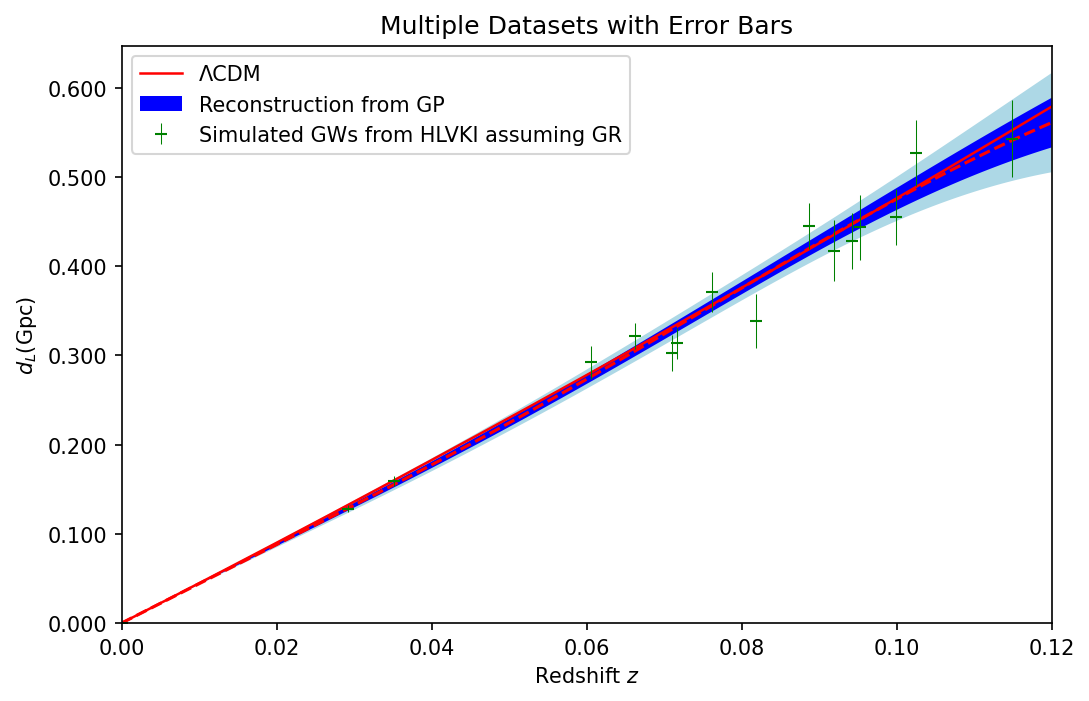

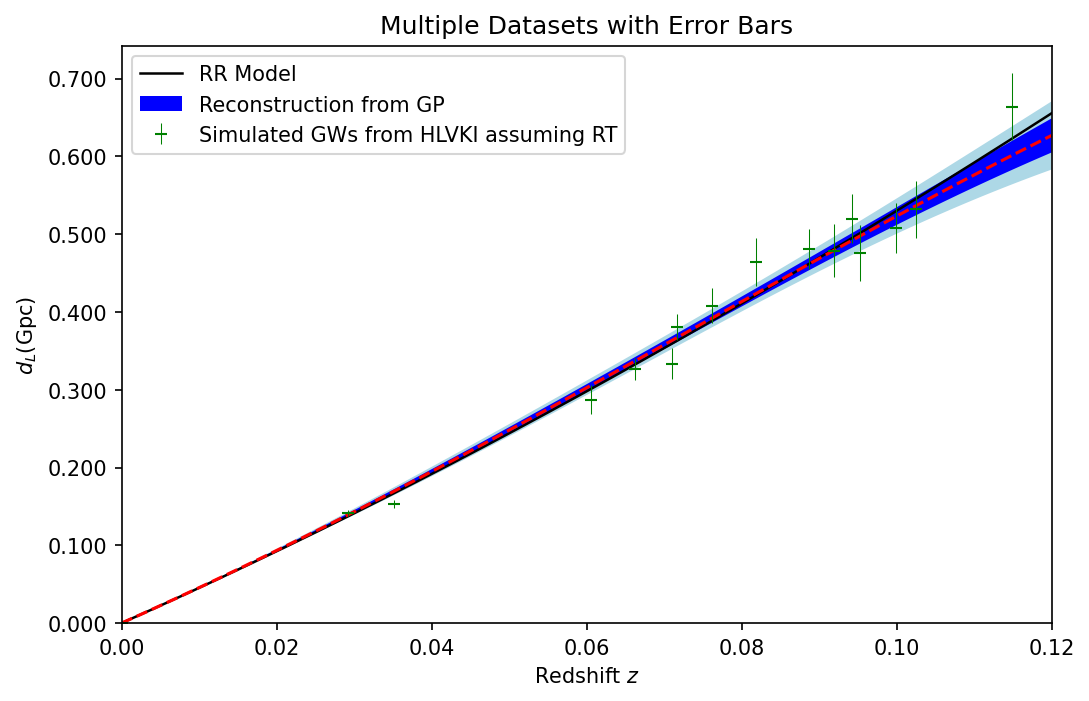

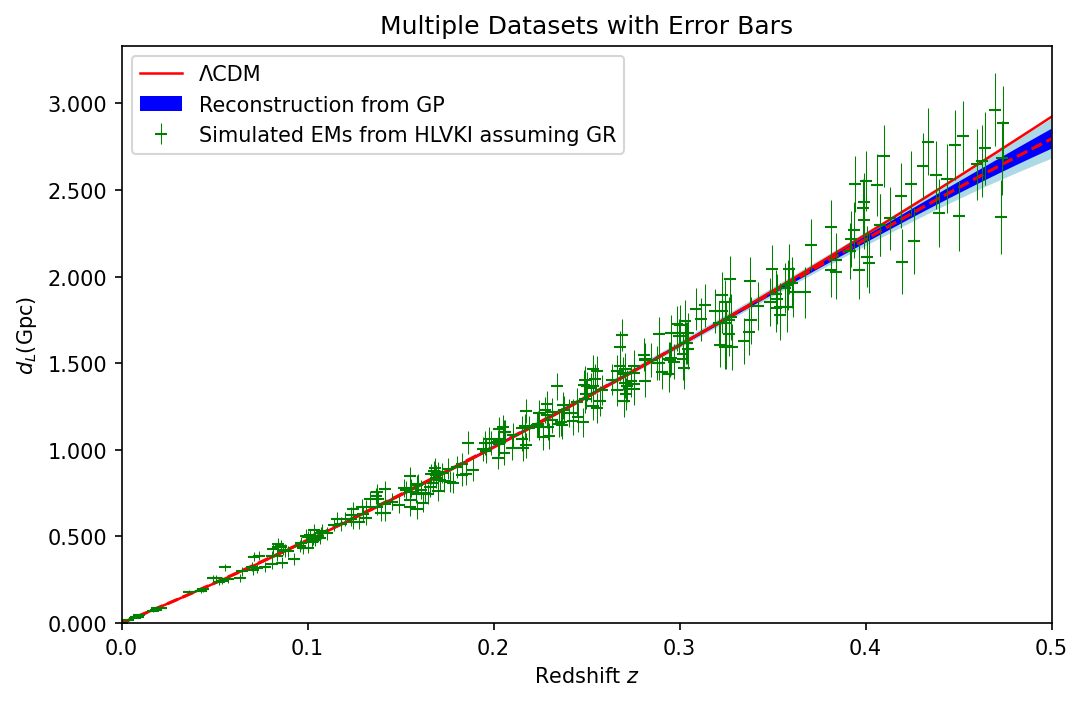

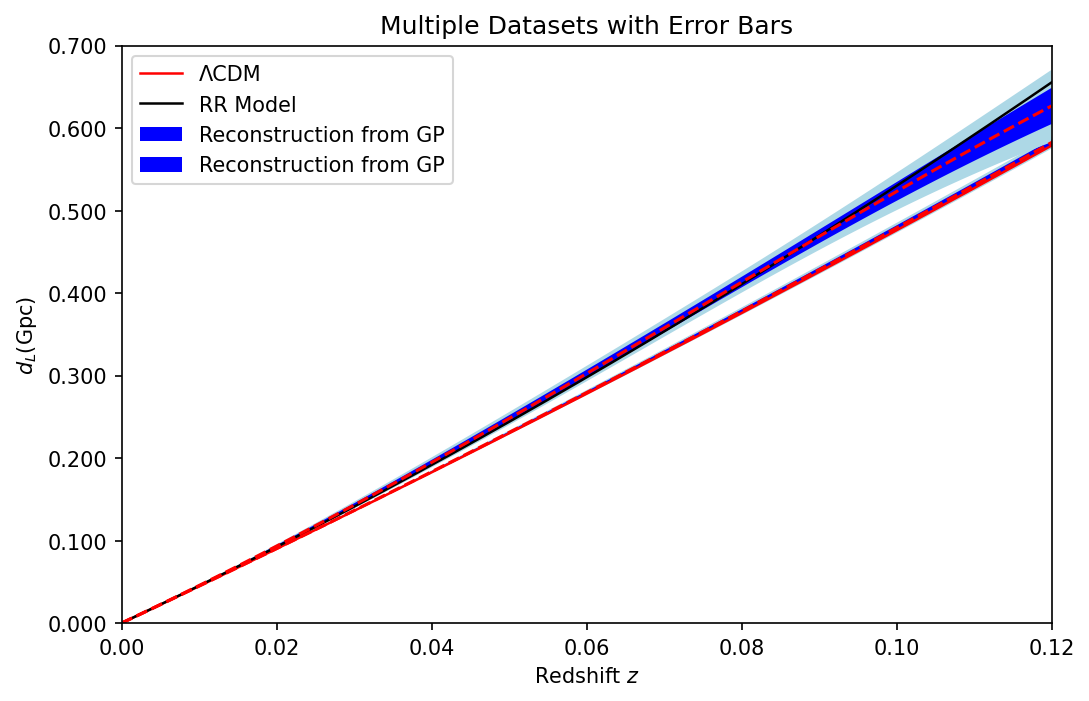

In [39]:
plt.figure(figsize=(8,5),dpi=150)  # 先创建 figure
plot_line(GW_forplot_ACDM(H0=67.64, Omega_M=0.3087, z_max=0.12, n_points=200), label='ΛCDM', linecolor='red')
plot_gapp(dataACDM_GW, Label='Reconstruction from GP')
plot_spot_with_error(ACDM_csv_to_newnumpy('Data/GR_GW.csv'), label='Simulated GWs from HLVKI assuming GR', fmt='_', color='green')
plot_show(xlimDOWN=0,xlimUP=0.12,ylimDOWN=0,xlabel="Redshift $z$", ylabel="$d_L$(Gpc)", title="Multiple Datasets with Error Bars", zoom=1000.0)

plt.figure(figsize=(8,5),dpi=150)  # 先创建 figure
plot_line(GW_forplot_RT(Xi=1.67, n=1.94, z_max=0.12, n_points=200), label='RR Model', linecolor='black')
# plot_gapp(gapp_solve(GT_csv_to_newnumpy('Data/GR_GW.csv'), xmin=0, xmax=0.12, nstar=1000, initheta=[0.2,0.01]), Label='Reconstruction from GP')
plot_gapp(dataGR_GW, Label='Reconstruction from GP')
plot_spot_with_error(GT_csv_to_newnumpy('Data/GR_GW.csv'), label='Simulated GWs from HLVKI assuming RT', fmt='_', color='green')
plot_show(xlimDOWN=0,xlimUP=0.12,ylimDOWN=0,xlabel="Redshift $z$", ylabel="$d_L$(Gpc)", title="Multiple Datasets with Error Bars", zoom=1000.0)

plt.figure(figsize=(8,5),dpi=150)  # 先创建 figure
plot_line(GW_forplot_ACDM(H0=67.64, Omega_M=0.3087, z_max=0.5, n_points=200), label='ΛCDM', linecolor='red')
# plot_gapp(gapp_solve(ACDM_csv_to_newnumpy('Data/outputEM.csv'), xmin=0, xmax=0.5, nstar=1000, initheta=[2.0,0.01]), Label='Reconstruction from GP')
plot_gapp(dataGR_EM, color ="red",Label='Reconstruction from GP')
plot_spot_with_error(ACDM_csv_to_newnumpy('Data/outputEM.csv'), label='Simulated EMs from HLVKI assuming GR', fmt='_', color='green')
plot_show(xlimDOWN=0,xlimUP=0.5,ylimDOWN=0, xlabel="Redshift $z$", ylabel="$d_L$(Gpc)", title="Multiple Datasets with Error Bars", zoom=1000.0)

plt.figure(figsize=(8,5),dpi=150)  # 先创建 figure
plot_line(GW_forplot_ACDM(H0=67.64, Omega_M=0.3087, z_max=0.12, n_points=200), label='ΛCDM', linecolor='red')
plot_line(GW_forplot_RT(Xi=1.67, n=1.94, z_max=0.12, n_points=200), label='RR Model', linecolor='black')
plot_gapp(dataGR_EM, color ="red",Label='Reconstruction from GP')
# plot_gapp(gapp_solve(GT_csv_to_newnumpy('Data/GR_GW.csv'), xmin=0, xmax=0.12, nstar=1000, initheta=[2.0,0.01]),color="black", Label='GW Reconstruction from GP')
plot_gapp(dataGR_GW, Label='Reconstruction from GP')
plot_show(xlimDOWN=0,xlimUP=0.12,ylimDOWN=0,ylimUP=700,xlabel="Redshift $z$", ylabel="$d_L$(Gpc)", title="Multiple Datasets with Error Bars", zoom=1000.0)


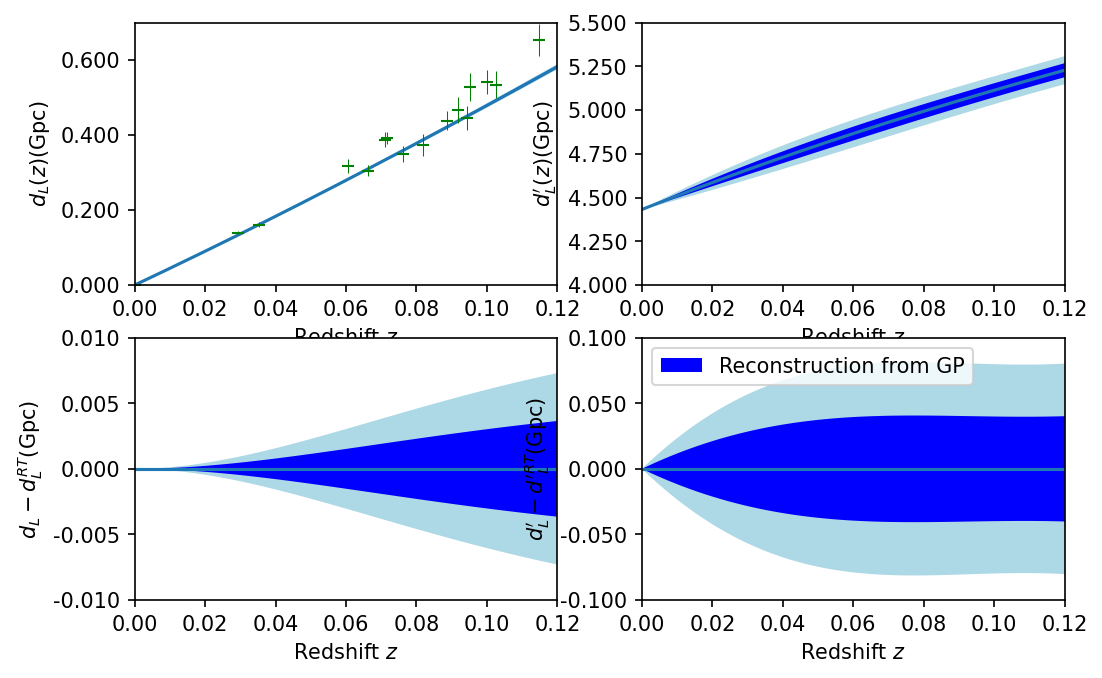

In [94]:
plot_gapp_assemble_dL(dataGR_EM, color ="red",Label = "Reconstruction from GP")

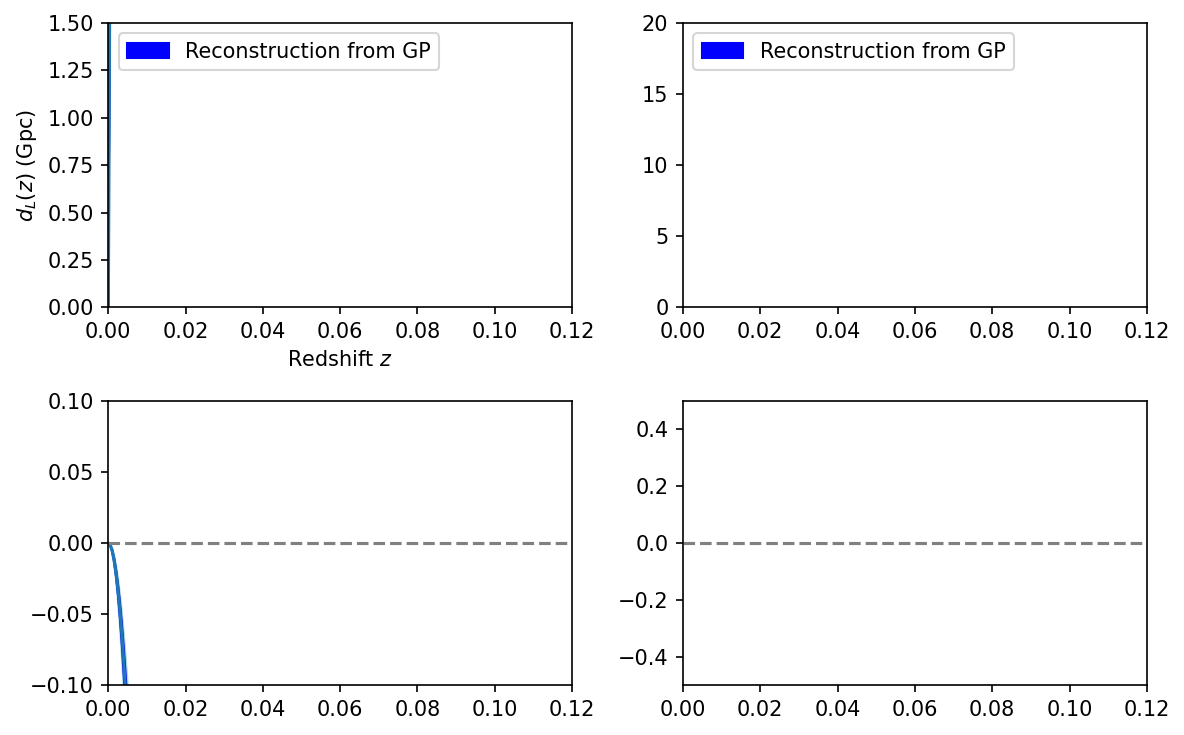

In [79]:
rec = dataGR_EM["rec"]
drec = dataGR_EM["drec"]
fig, axs = plt.subplots(2, 2, figsize=(8,5), dpi=150)
Label = "Reconstruction from GP"

zoom=float(1000.0)

RT_data = GW_calculate_RT(z=rec[:, 0], Xi=1.67, n=1.94, c=299792.458)
dl_RT = RT_data[:, 1]
dl_rec = rec[:, 1]
delta_dl = dl_rec - dl_RT

dl_prime_RT = np.gradient(RT_data[:,1], RT_data[:,0])
dl_prime_rec = drec[:, 1]
delta_prime = dl_prime_rec - dl_prime_RT
# ===== 1. d_L =====
ax = axs[0,0]
ax.set_xlim(0, 0.12)
ax.set_ylim(0, 1.5)   # ⭐ 自己调

ax.fill_between(rec[:,0], rec[:,1]-2*rec[:,2], rec[:,1]+2*rec[:,2], color='lightblue')
ax.fill_between(rec[:,0], rec[:,1]-rec[:,2], rec[:,1]+rec[:,2], color='blue', label=Label)
ax.plot(rec[:,0], rec[:,1])

ax.legend(loc='upper left')   # ⭐ 只在这里
ax.set_xlabel('Redshift $z$')
ax.set_ylabel('$d_L(z)$ (Gpc)')


# ===== 2. d_L' =====
ax = axs[0,1]
ax.set_xlim(0, 0.12)
ax.set_ylim(0, 20)

ax.fill_between(drec[:,0], drec[:,1]-2*drec[:,2], drec[:,1]+2*drec[:,2], color='lightblue')
ax.fill_between(drec[:,0], drec[:,1]-drec[:,2], drec[:,1]+drec[:,2], color='blue', label=Label)
ax.plot(drec[:,0], drec[:,1])

ax.legend(loc='upper left')   # ⭐ 只在这里


# ===== 3. Δd_L =====
ax = axs[1,0]
ax.set_xlim(0, 0.12)
ax.set_ylim(-0.1, 0.1)

ax.fill_between(rec[:,0], delta_dl-2*rec[:,2], delta_dl+2*rec[:,2], color='lightblue')
ax.fill_between(rec[:,0], delta_dl-rec[:,2], delta_dl+rec[:,2], color='blue')
ax.plot(rec[:,0], delta_dl)

ax.axhline(0, linestyle='--', color='gray')   # ⭐ 必须


# ===== 4. Δd_L' =====
ax = axs[1,1]
ax.set_xlim(0, 0.12)
ax.set_ylim(-0.5, 0.5)

ax.fill_between(drec[:,0], delta_prime-2*drec[:,2], delta_prime+2*drec[:,2], color='lightblue')
ax.fill_between(drec[:,0], delta_prime-drec[:,2], delta_prime+drec[:,2], color='blue')
ax.plot(drec[:,0], delta_prime)

ax.axhline(0, linestyle='--', color='gray')


plt.tight_layout()
plt.show()

# 二阶重构

## 计算理论比值

In [40]:
def Dz_GR(z_max,n_point):
    x = np.linspace(0,z_max,n_point)
    y = np.full_like(x, 1.0)
    Dz = np.column_stack((x,y))
    return Dz
    

In [41]:
# 输入：最大值和需要拟合点的个数（平均取点） -> 输出一个二维数组
def Dz_RT(z_max,n_point):
    x = np.linspace(0,z_max,n_point) 
    d_EM = GW_calculate_ACDM(H0=67.64, Omega_M=0.3087, z=x, c=c_light)
    d_GW = GW_calculate_RT(Xi=1.67, n=1.94, z=x, c=c_light)

    # 处理 0/0 的情况
    y = np.zeros_like(x)
    y[1:] = d_GW[1:,1] / d_EM[1:,1]
    y[0] = 1.0  # 理论上在z=0时应相等

    Dz = np.column_stack((x,y))
    return Dz

# Dz = Dz_RT(1.2,100)
# print(Dz[:10])

## 计算实验重构比值

In [42]:
def Dz_gapp_GR():
    # GWz =gapp_solve (GT_csv_to_newnumpy('Data/GR_GW.csv'), xmin=0, xmax=0.12, nstar=1000, initheta=[1000.0,0.01])
    GWz = dataGR_GW
    # EMz = gapp_solve(ACDM_csv_to_newnumpy('Data/outputEM.csv'), xmin=0, xmax=0.12, nstar=1000, initheta=[200.0,0.01])
    EMz = dataGR_EM

    recGW = GWz["rec"]
    recEM = EMz["rec"]

    # x1, y1, sigma1 = recGW[:,0], recGW[:,1], recGW[:,2]
    # x2, y2, sigma2 = recEM[:,0], recEM[:,1], recEM[:,2]

    # Dz = y1 / y2 
    
    # Sigma = np.sqrt( (sigma1/y2)**2 + (y1*sigma2/(y2)**2)**2 )

    
    # data = np.column_stack((x1,Dz,Sigma))
    # print(y2)
    # print(y2)
    
    # data[0, 1] = 1.0
    # data[0, 2] = 0.0
    # print(Sigma)
    data = montecarlo_ratio_group(recGW,recEM,500000)
    return data
# Dz_gapp_GR()


<>:3: SyntaxWarning: invalid escape sequence '\X'
<>:3: SyntaxWarning: invalid escape sequence '\X'
/var/folders/gg/tq10bl_14jgc1xk6pjs_s4dm0000gn/T/ipykernel_6746/466375752.py:3: SyntaxWarning: invalid escape sequence '\X'
  plot_line(Dz_RT(1.2,100), label='fiducial D(z) assuming RT: $\Xi_0 =1.67, n=1.94$', linecolor='black')


montecarlo_ratio_group
[########################################]

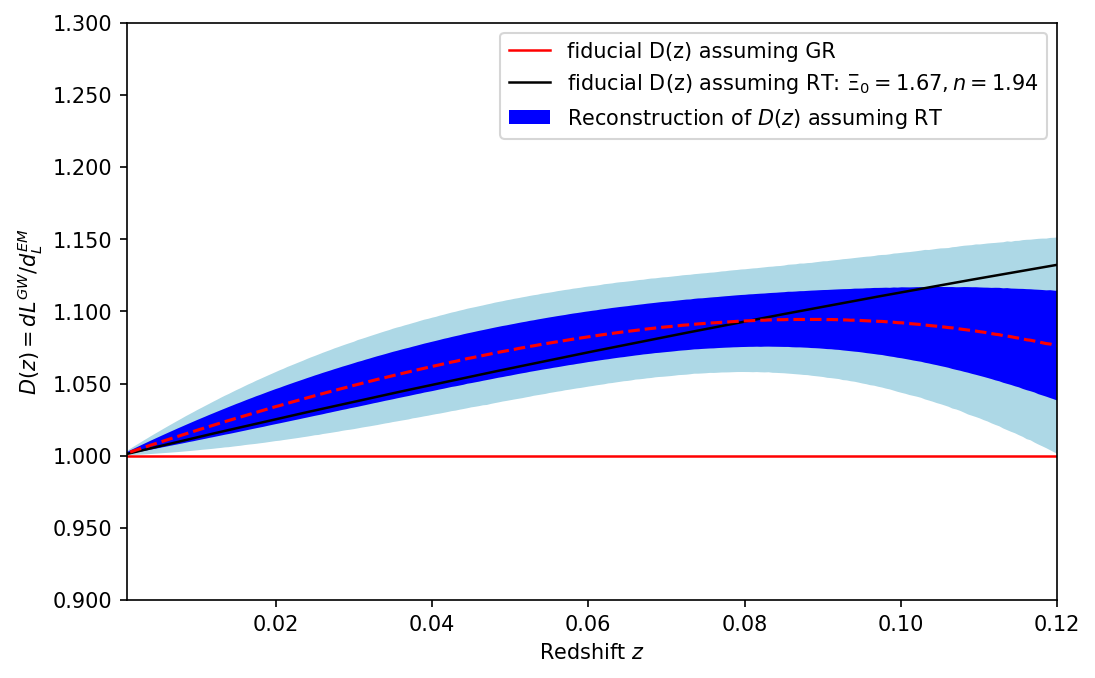

In [43]:
plt.figure(figsize=(8,5),dpi=150)  # 先创建 figure
plot_line(Dz_GR(1.2,100), label='fiducial D(z) assuming GR', linecolor='red')
plot_line(Dz_RT(1.2,100), label='fiducial D(z) assuming RT: $\Xi_0 =1.67, n=1.94$', linecolor='black')
plot_montecarlo(Dz_gapp_GR(), Label='Reconstruction of $D(z)$ assuming RT')
# plot_gapp(gapp_solve(Dz_gapp_GR(), xmin=0, xmax=0.12, nstar=200, initheta=[20.0,0.04]), Label='Reconstruction from GP')
plot_show(xlimDOWN=0.001,xlimUP=0.12,ylimDOWN=0.9, ylimUP=1.30, xlabel="Redshift $z$", ylabel="$D(z)= dL^{GW} / d_L^{EM}$",zoom=1)

# 三阶重构

## 牛顿引力常数的重构

In [44]:
def Gravity_RT(z_max,npoints):
    data = Dz_RT(z_max,npoints)
    y = (data[:,1] ** 2) 
    x = data[:,0]
    Gravity = np.column_stack((x,y))
    return Gravity

In [45]:
def Gravity_gapp_RT(n_sample=500000):
    data = Dz_gapp_GR()
    Gravity = montecarlo_gravity_group(data,n_sample)
    return Gravity
# Gravity_gapp_RT()

montecarlo_ratio_group
[########################################]
 montecarlo_gravity_group
[########################################]

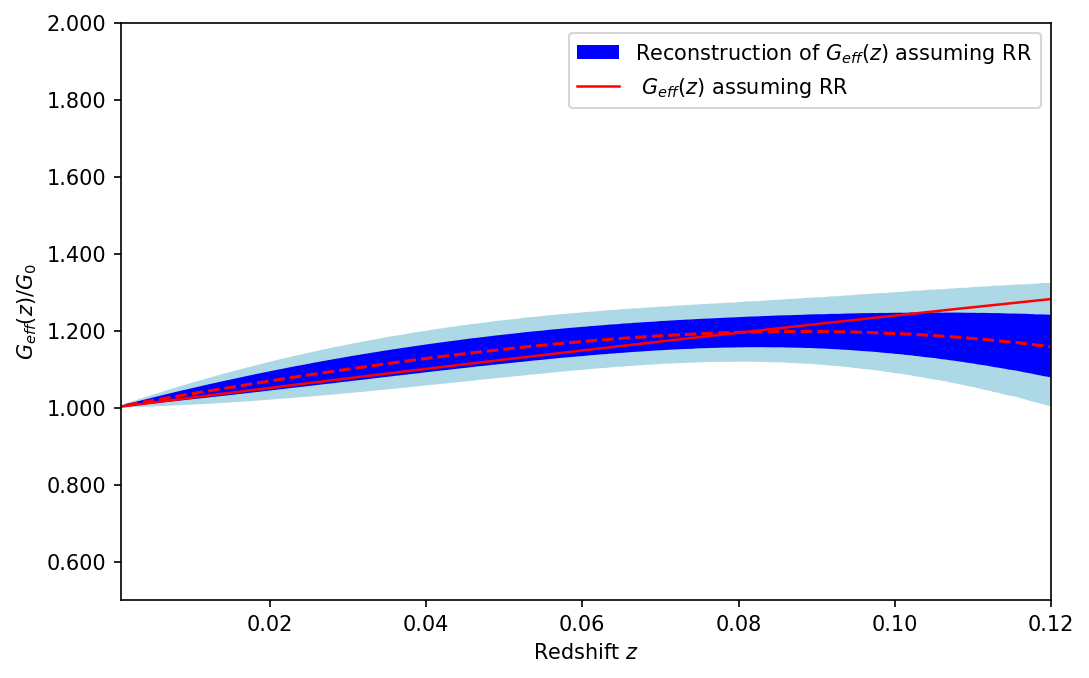

In [46]:
plt.figure(figsize=(8,5),dpi=150)  # 先创建 figure
plot_montecarlo(Gravity_gapp_RT(), Label='Reconstruction of $G_{eff}(z)$ assuming RR')
# plot_gapp(gapp_solve(Dz_gapp_GR(), xmin=0, xmax=0.12, nstar=200, initheta=[20.0,0.04]), Label='Reconstruction from GP')
plot_line(Gravity_RT(1.2,100), label=' $G_{eff}(z)$ assuming RR', linecolor='red')
plot_show(xlimDOWN=0.001,xlimUP=0.12,ylimDOWN=0.5,ylimUP=2.0, xlabel="Redshift $z$", ylabel="$G_{eff}(z)/G_0$",zoom=1)


## 时空维度 D的重构

In [47]:
def dimention_ACDM(z_max,n_point):
    x = np.linspace(0,z_max,n_point) 
    y = np.full_like(x, 4.0)
    
    dimention=np.column_stack((x, y))
    return dimention

In [48]:
def dimention_gapp_ACDM():
    GWz = dataACDM_GW
    # EMz = gapp_solve(ACDM_csv_to_newnumpy('Data/outputEM.csv'), xmin=0, xmax=0.12, nstar=1000, initheta=[200.0,0.01])
    EMz = dataGR_EM

    recGW = GWz["rec"]
    recEM = EMz["rec"]
    data = montecarlo_dimention_group(recGW,recEM,500000)
    return data


 montecarlo_dimention_group
[##########################              ]

/var/folders/gg/tq10bl_14jgc1xk6pjs_s4dm0000gn/T/ipykernel_6746/1346011892.py:8: RuntimeWarning: invalid value encountered in log
  numerator = 2 * n * np.log(samplesA / samplesB)


[########################################]

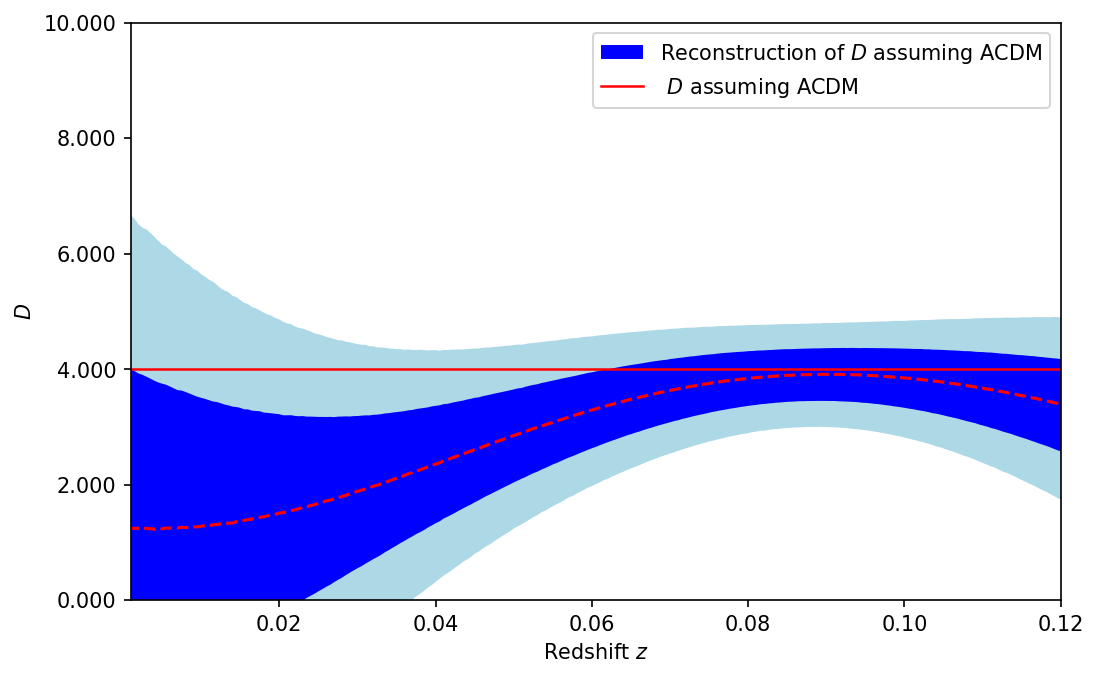

In [49]:
plt.figure(figsize=(8,5),dpi=150)  # 先创建 figure
plot_montecarlo(dimention_gapp_ACDM(), Label='Reconstruction of $D$ assuming ACDM')
# plot_gapp(gapp_solve(Dz_gapp_GR(), xmin=0, xmax=0.12, nstar=200, initheta=[20.0,0.04]), Label='Reconstruction from GP')
plot_line(dimention_ACDM(1.2,100), label=' $D$ assuming ACDM', linecolor='red')
plot_show(xlimDOWN=0.001,xlimUP=0.12,ylimDOWN=0.0,ylimUP=10.0, xlabel="Redshift $z$", ylabel="$D$",zoom=1)